# CHARMS Pipeline

Cross-modal knowledge transfer on top of the DINOv2 baseline, following Jiang et al., *Tabular Insights, Visual Impacts: Transferring Expertise from Tables to Images* (ICML 2024).

**Image trunk is identical to the baseline** — frozen DINOv2 CLS (384-d) → `Encoder(384→128→32)` → `BiomassHead(32→32→5)` — so at inference CHARMS is a drop-in replacement.

**Training adds three things:**

1. A small **FT-Transformer-lite** tabular encoder over (NDVI, Height, State, Month).
2. A **Sinkhorn optimal-transport** alignment between the 32 latent channels and the 4 tabular attributes. The transport matrix `T ∈ R^{D×C}` is recomputed every 5 epochs.
3. An **image-to-tabular auxiliary loss** (paper eq. 8): for each attribute, gate the image latent with row `T[d]` and predict that attribute.

Combined loss (paper eq. 7):

$$\mathcal{L} = \underbrace{\ell(f(x^I), y)}_{\text{image biomass}} + \lambda_{\text{tab}}\, \underbrace{\ell(g(x^T), y)}_{\text{tabular biomass}} + \lambda_{\text{num}}\!\sum_p \text{MSE}(T_p\!\cdot\phi(x^I), x^{\text{num}}_p) + \lambda_{\text{cat}}\!\sum_q \text{CE}(T_q\!\cdot\phi(x^I), x^{\text{cat}}_q)$$

Set `SKIP_TRAINING = True` to reload a saved checkpoint instead of re-training.

## 1. Imports and Configuration

Load dependencies and define `CharmsConfig` alongside training hyperparameters. Optimizer / scheduler / batch size / epochs **match the baseline exactly** so any R² delta is attributable to the CHARMS loss.

In [1]:
# Bootstrap: make src/ importable from notebooks in src/methods/charms/
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

In [2]:
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader

from shared.metrics import TARGETS
from shared.model import BiomassModel
from shared.train import eval_epoch as baseline_eval_epoch
from shared.data_utils import load_datasets
from methods.charms.charms import (
    CharmsConfig, BiomassCharmsModel, load_charms_datasets,
)
from methods.charms.train_charms import train, eval_epoch

REPO_ROOT  = Path('../../..')
CACHE_DIR  = REPO_ROOT / 'src' / 'cache'
CKPT_DIR   = REPO_ROOT / 'src' / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# Training config — matches baseline_pipeline.ipynb for apples-to-apples comparison
cfg_train = dict(
    seed         = 42,
    epochs       = 80,
    lr           = 3e-4,
    weight_decay = 1e-3,
    batch_size   = 32,
)

SKIP_TRAINING = False  # set True to reload charms.pt instead of re-training

device = (
    'mps'  if torch.backends.mps.is_available()  else
    'cuda' if torch.cuda.is_available()          else 'cpu'
)
print(f'Device : {device}')
print('Train cfg :', cfg_train)

Device : cpu
Train cfg : {'seed': 42, 'epochs': 80, 'lr': 0.0003, 'weight_decay': 0.001, 'batch_size': 32}


## 2. Feature Cache Check

CHARMS reuses the baseline's cached DINOv2 features — no re-extraction is needed. If the cache is missing, run `src/shared/baseline_pipeline.ipynb` first (cell 2).

In [3]:
from shared.extract_features import (
    DINOV2_CACHE, IDS_CACHE, TEST_IMAGE_CACHE, TEST_IDS_CACHE,
)

assert DINOV2_CACHE.exists() and IDS_CACHE.exists(), (
    'Training feature cache missing — run src/shared/baseline_pipeline.ipynb '
    '(or src/shared/extract_features.py) first.'
)
print(f'Train features : {np.load(DINOV2_CACHE).shape}')
if TEST_IMAGE_CACHE.exists():
    print(f'Test  features : {np.load(TEST_IMAGE_CACHE).shape}')
else:
    print('Test  features : NOT CACHED (submission step will be skipped)')

Train features : (357, 384)
Test  features : (1, 384)


## 3. Data Loading

`load_charms_datasets` builds `CharmsDataset` pairs over the **same** GroupKFold split the baseline uses. Each sample yields `(X, y, num, cat)`:

| Field | Shape | Content |
|-------|-------|---------|
| `X`   | (384,) float32 | DINOv2 CLS feature |
| `y`   | (5,)   float32 | Biomass targets |
| `num` | (2,)   float32 | z-scored NDVI, Height |
| `cat` | (2,)   int64   | label-encoded State, Month |

In [4]:
CSV_PATH = REPO_ROOT / 'data' / 'tabular' / 'train' / 'train.csv'

train_ds, val_ds, meta = load_charms_datasets(CSV_PATH, CACHE_DIR)

print(f'Train samples : {len(train_ds)}')
print(f'Val   samples : {len(val_ds)}')
print(f'Feature dim   : {train_ds[0]["X"].shape[0]}')
print(f'Numeric attrs      : {meta.numeric_attrs}')
print(f'Categorical attrs  : {meta.categorical_attrs}')
print(f'Cat cardinalities  : {meta.cat_cardinalities}')
for name, classes in zip(meta.categorical_attrs, meta.cat_classes):
    print(f'  {name} classes: {classes}')

Train samples : 285
Val   samples : 72
Feature dim   : 384
Numeric attrs      : ['Pre_GSHH_NDVI', 'Height_Ave_cm']
Categorical attrs  : ['State', 'month']
Cat cardinalities  : [4, 10]
  State classes: ['NSW', 'Tas', 'Vic', 'WA']
  month classes: ['1', '10', '11', '2', '4', '5', '6', '7', '8', '9']


## 4. Model Initialization

`BiomassCharmsModel` wraps the baseline `Encoder` and `BiomassHead` unchanged, then adds:

- a small FT-Transformer over 4 attribute tokens (`TabularEncoder`),
- 2 numeric aux heads (NDVI, Height) and 2 categorical aux heads (State, Month),
- a `transport` buffer `T ∈ R^{D×C}` holding the current OT alignment.

All extras are discarded at inference, so the image path is byte-identical to the baseline.

In [5]:
torch.manual_seed(cfg_train['seed'])

cfg_charms = CharmsConfig(
    # Baseline-matched architecture
    input_dim   = 384,
    latent_dim  = 32,
    output_dim  = 5,
    dropout     = 0.1,
    # Metadata schema (populated from loaded data)
    numeric_attrs     = tuple(meta.numeric_attrs),
    categorical_attrs = tuple(meta.categorical_attrs),
    cat_cardinalities = tuple(meta.cat_cardinalities),
    # CHARMS OT alignment
    sinkhorn_epsilon    = 0.05,
    sinkhorn_iters      = 50,
    similarity_sigma    = 1.0,
    cost_update_every   = 5,
    cost_update_samples = 256,
    # Loss weights (primary objective remains image biomass)
    lambda_tab     = 0.5,
    lambda_i2t_num = 0.25,
    lambda_i2t_cat = 0.10,
)

model = BiomassCharmsModel(cfg_charms).to(device)

# Parameter breakdown: image trunk vs added CHARMS machinery
n_trunk = sum(p.numel() for p in list(model.encoder.parameters()) + list(model.biomass_head.parameters()))
n_tab   = sum(p.numel() for p in model.tab_encoder.parameters())
n_aux   = sum(p.numel() for h in list(model.num_aux_heads) + list(model.cat_aux_heads) for p in h.parameters())
n_total = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Image trunk (matches baseline) : {n_trunk:>8,} params')
print(f'Tabular FT-Transformer         : {n_tab:>8,} params')
print(f'Auxiliary heads                : {n_aux:>8,} params')
print(f'Total CHARMS trainable         : {n_total:>8,} params')
print(f'Transport T shape              : {tuple(model.transport.shape)}  (D={model.transport.shape[0]} attrs, C={model.transport.shape[1]} latent channels)')

Image trunk (matches baseline) :   54,629 params
Tabular FT-Transformer         :   72,773 params
Auxiliary heads                :    4,752 params
Total CHARMS trainable         :  132,154 params
Transport T shape              : (4, 32)  (D=4 attrs, C=32 latent channels)


c:\Users\somme\anaconda3\envs\INF265\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## 5. Training

The CHARMS training loop wraps the baseline optimizer + scheduler (AdamW, cosine-annealing LR). Each step minimises the combined loss; every `cost_update_every` epochs the transport matrix `T` is recomputed from 256 training samples via:

1. Forward → `(N, 32)` latent
2. Tabular forward → `(N, 4, 64)` attribute embeddings
3. Build N×N sample similarity per channel (Gaussian on scalar latent) and per attribute (cosine on token embeddings)
4. Cost `C[d,c] = mean((S_T[d] - S_I[c])²)`
5. Sinkhorn iterations → new `T`

Validation uses only the image branch (`model(x)`) — identical code path to the baseline — so the reported R² is directly comparable.

In [6]:
ckpt_path = CKPT_DIR / 'charms.pt'

if SKIP_TRAINING and ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    history = ckpt.get('history', {})
    print(f'Loaded checkpoint from {ckpt_path}')
else:
    history = train(
        model, train_ds, val_ds,
        epochs       = cfg_train['epochs'],
        batch_size   = cfg_train['batch_size'],
        lr           = cfg_train['lr'],
        weight_decay = cfg_train['weight_decay'],
        seed         = cfg_train['seed'],
        device       = device,
        verbose      = True,
    )
    torch.save({'model_state_dict': model.state_dict(), 'history': history}, ckpt_path)
    print(f'\nCheckpoint saved: {ckpt_path}')

  ep   1  L_img=6.5575  L_tab=6.5572  L_num=2.1468  L_cat=3.7003  val_L=6.9612  val_R²=-1.0688  [Green:37.49  Dead:16.04  Clover:14.95  g:43.56  Total:54.04]
  ep   5  L_img=5.1392  L_tab=6.3199  L_num=1.7208  L_cat=3.6281  val_L=5.0724  val_R²=-0.4358  [Green:32.69  Dead:17.07  Clover:14.33  g:38.18  Total:40.79]
  ep  10  L_img=3.2651  L_tab=5.9407  L_num=0.8898  L_cat=3.5387  val_L=3.4415  val_R²=0.2088  [Green:25.84  Dead:13.16  Clover:13.99  g:28.57  Total:26.95]
  ep  15  L_img=2.7165  L_tab=5.4269  L_num=0.6887  L_cat=3.3802  val_L=2.7809  val_R²=0.4382  [Green:22.20  Dead:11.83  Clover:13.60  g:23.14  Total:20.85]
  ep  20  L_img=2.4281  L_tab=4.8397  L_num=0.5115  L_cat=3.2762  val_L=2.5099  val_R²=0.5298  [Green:20.00  Dead:11.53  Clover:13.61  g:20.33  Total:18.21]
  ep  25  L_img=2.1787  L_tab=4.2583  L_num=0.4155  L_cat=3.1452  val_L=2.3171  val_R²=0.5942  [Green:18.43  Dead:11.32  Clover:13.59  g:18.08  Total:16.58]
  ep  30  L_img=2.1894  L_tab=3.8556  L_num=0.3889  L_ca

## 6. Validation Results (image-only)

Weighted global R² and per-target RMSE on the held-out GroupKFold validation fold, using **only the image forward path** — the tabular branch and aux heads are dropped at inference.

In [7]:
val_loader = DataLoader(val_ds, batch_size=cfg_train['batch_size'], shuffle=False, num_workers=0)
val_loss, val_r2, val_rmse, y_pred, y_true = eval_epoch(model, val_loader, device)

print(f'CHARMS — image-only validation')
print(f'  Loss       : {val_loss:.4f}')
print(f'  Weighted R²: {val_r2:.4f}')
print()
print(f'{"Target":<20}  RMSE')
print('-' * 32)
for t in TARGETS:
    print(f'  {t:<18}  {val_rmse[t]:.4f}')

CHARMS — image-only validation
  Loss       : 2.0253
  Weighted R²: 0.6693

Target                RMSE
--------------------------------
  Dry_Green_g         16.4711
  Dry_Dead_g          11.2426
  Dry_Clover_g        13.3652
  GDM_g               14.3774
  Dry_Total_g         14.8562


## 7. Baseline vs CHARMS comparison

Load the baseline checkpoint (from `shared/baseline_pipeline.ipynb`) and evaluate it on the **same** validation fold with the **same** evaluator — any R² delta is attributable to CHARMS.

In [8]:
baseline_ckpt = CKPT_DIR / 'baseline.pt'
baseline_r2 = None
baseline_rmse = None

if not baseline_ckpt.exists():
    print(f'No baseline checkpoint at {baseline_ckpt} — run src/shared/baseline_pipeline.ipynb first.')
else:
    # Same data path as baseline; shared.data_utils.load_datasets builds a
    # BiomassFeatureDataset over the same GroupKFold fold-0 split.
    b_train_ds, b_val_ds = load_datasets(CSV_PATH, CACHE_DIR)
    b_val_loader = DataLoader(b_val_ds, batch_size=cfg_train['batch_size'], shuffle=False, num_workers=0)

    baseline = BiomassModel(input_dim=384, latent_dim=32, output_dim=5, dropout=0.1).to(device)
    b_ckpt = torch.load(baseline_ckpt, map_location=device, weights_only=False)
    baseline.load_state_dict(b_ckpt['model_state_dict'])

    b_loss, baseline_r2, baseline_rmse, _, _ = baseline_eval_epoch(baseline, b_val_loader, device)
    print(f'Baseline (DINOv2 + Encoder + BiomassHead)')
    print(f'  Loss       : {b_loss:.4f}')
    print(f'  Weighted R²: {baseline_r2:.4f}')
    print()
    print(f'{"Target":<20}  Baseline RMSE    CHARMS RMSE      Δ')
    print('-' * 64)
    for t in TARGETS:
        delta = val_rmse[t] - baseline_rmse[t]
        arrow = '↓ better' if delta < 0 else '↑ worse '
        print(f'  {t:<18}  {baseline_rmse[t]:>10.4f}      {val_rmse[t]:>10.4f}   {delta:+7.4f}  {arrow}')
    print()
    delta_r2 = val_r2 - baseline_r2
    winner = 'CHARMS better' if delta_r2 > 0 else 'baseline better'
    print(f'ΔR² = {delta_r2:+.4f}   ({winner})')

Baseline (DINOv2 + Encoder + BiomassHead)
  Loss       : 1.9897
  Weighted R²: 0.6793

Target                Baseline RMSE    CHARMS RMSE      Δ
----------------------------------------------------------------
  Dry_Green_g            16.2164         16.4711   +0.2547  ↑ worse 
  Dry_Dead_g             11.2059         11.2426   +0.0367  ↑ worse 
  Dry_Clover_g           13.6172         13.3652   -0.2519  ↓ better
  GDM_g                  13.8404         14.3774   +0.5369  ↑ worse 
  Dry_Total_g            14.5873         14.8562   +0.2689  ↑ worse 

ΔR² = -0.0099   (baseline better)


## 8. Training Curves

Each CHARMS loss term plotted separately so you can see whether it is actually doing useful work. Dashed vertical lines mark transport-matrix refresh epochs.

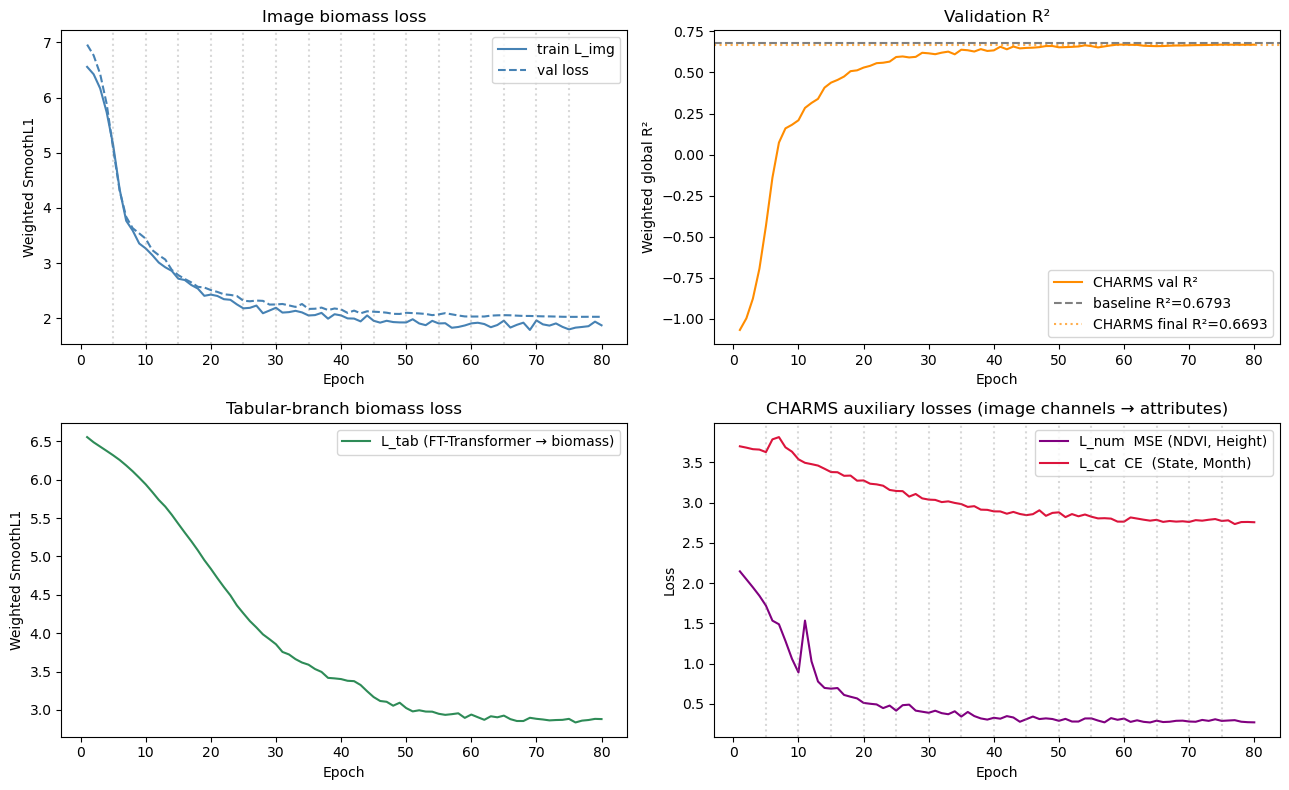

In [9]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history['train_img']) + 1)
refresh_epochs = [e for e in history.get('transport_updates', []) if e > 0]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Panel 1 — image biomass train + val
ax = axes[0, 0]
ax.plot(epochs_range, history['train_img'], label='train L_img', color='steelblue')
ax.plot(epochs_range, history['val_loss'],  label='val loss',    color='steelblue', linestyle='--')
for ep in refresh_epochs:
    ax.axvline(ep, color='grey', linestyle=':', alpha=0.3)
ax.set_xlabel('Epoch'); ax.set_ylabel('Weighted SmoothL1')
ax.set_title('Image biomass loss'); ax.legend()

# Panel 2 — validation R² vs baseline
ax = axes[0, 1]
ax.plot(epochs_range, history['val_r2'], label='CHARMS val R²', color='darkorange')
if baseline_r2 is not None:
    ax.axhline(baseline_r2, color='grey', linestyle='--', label=f'baseline R²={baseline_r2:.4f}')
ax.axhline(val_r2, color='darkorange', linestyle=':', alpha=0.7, label=f'CHARMS final R²={val_r2:.4f}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Weighted global R²')
ax.set_title('Validation R²'); ax.legend()

# Panel 3 — tabular-branch loss
ax = axes[1, 0]
ax.plot(epochs_range, history['train_tab'], label='L_tab (FT-Transformer → biomass)', color='seagreen')
ax.set_xlabel('Epoch'); ax.set_ylabel('Weighted SmoothL1')
ax.set_title('Tabular-branch biomass loss'); ax.legend()

# Panel 4 — CHARMS auxiliary losses
ax = axes[1, 1]
ax.plot(epochs_range, history['train_num'], label='L_num  MSE (NDVI, Height)', color='purple')
ax.plot(epochs_range, history['train_cat'], label='L_cat  CE  (State, Month)', color='crimson')
for ep in refresh_epochs:
    ax.axvline(ep, color='grey', linestyle=':', alpha=0.3)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('CHARMS auxiliary losses (image channels → attributes)'); ax.legend()

plt.tight_layout(); plt.show()

## 9. Transport Matrix Diagnostic

The learned transport matrix `T ∈ R^{D×C}` (rows = tabular attributes, cols = image latent channels). Each row indicates which latent channels CHARMS has tied to that attribute. Bright columns per row = channels that attribute "claims".

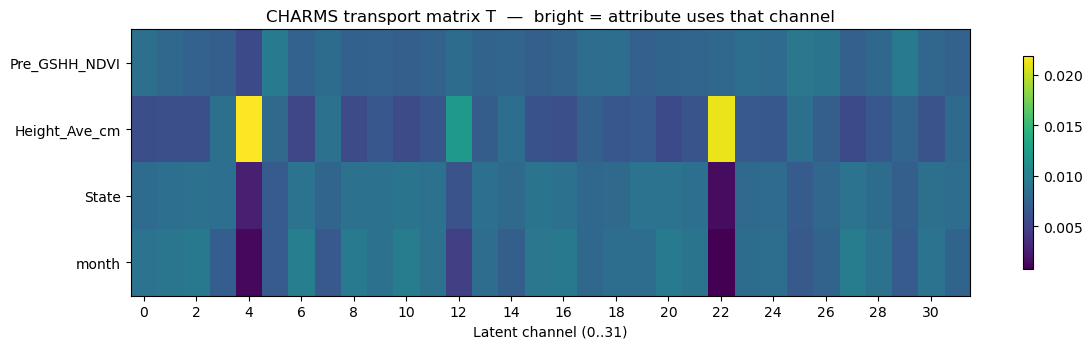


Top-5 latent channels per tabular attribute:
  Pre_GSHH_NDVI        → channels [29, 5, 25, 26, 0]  (weights [0.009580000303685665, 0.00949000008404255, 0.009119999594986439, 0.0088900001719594, 0.008510000072419643])
  Height_Ave_cm        → channels [4, 22, 12, 7, 25]  (weights [0.021849999204277992, 0.021199999377131462, 0.012079999782145023, 0.008750000037252903, 0.008550000376999378])
  State                → channels [15, 10, 6, 27, 19]  (weights [0.008899999782443047, 0.008899999782443047, 0.008820000104606152, 0.00880999956279993, 0.00877000018954277])
  month                → channels [6, 27, 10, 8, 20]  (weights [0.009809999726712704, 0.009669999592006207, 0.009600000455975533, 0.009560000151395798, 0.0094200000166893])


In [10]:
T = model.transport.detach().cpu().numpy()
D, C = T.shape
attr_names = list(meta.numeric_attrs) + list(meta.categorical_attrs)

fig, ax = plt.subplots(figsize=(12, 2 + 0.4 * D))
im = ax.imshow(T, aspect='auto', cmap='viridis')
ax.set_yticks(range(D)); ax.set_yticklabels(attr_names)
ax.set_xticks(range(0, C, 2)); ax.set_xticklabels(range(0, C, 2))
ax.set_xlabel(f'Latent channel (0..{C-1})')
ax.set_title('CHARMS transport matrix T  —  bright = attribute uses that channel')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

# Top-5 channels per attribute
print('\nTop-5 latent channels per tabular attribute:')
for d, name in enumerate(attr_names):
    top = np.argsort(-T[d])[:5]
    print(f'  {name:<20} → channels {top.tolist()}  (weights {T[d][top].round(5).tolist()})')

## 10. Kaggle Submission (optional)

CHARMS inference uses **only the image branch** — the tabular encoder and auxiliary heads are not invoked. Code mirrors the baseline's submission cell.

In [11]:
import pandas as pd

if not TEST_IMAGE_CACHE.exists():
    print('Test features not cached — re-run shared/baseline_pipeline.ipynb cell 2 first.')
else:
    test_feats = np.load(TEST_IMAGE_CACHE).astype(np.float32)
    test_ids   = np.load(TEST_IDS_CACHE, allow_pickle=True)

    model.eval()
    with torch.no_grad():
        preds = model(
            torch.tensor(test_feats, dtype=torch.float32, device=device)
        ).cpu().numpy()

    records = [
        {'sample_id': f'{img_id}__{target}', 'target': float(pred_row[t_idx])}
        for img_id, pred_row in zip(test_ids, preds)
        for t_idx, target in enumerate(TARGETS)
    ]
    sub_df = pd.DataFrame(records)

    sub_path = REPO_ROOT / 'src' / 'methods' / 'charms' / 'submission_charms.csv'
    sub_df.to_csv(sub_path, index=False)
    print(f'Submission saved: {sub_path}  ({len(sub_df)} rows)')
    sub_df.head()

Submission saved: ..\..\..\src\methods\charms\submission_charms.csv  (5 rows)
